# Modelagem do Stress Test Sintético (FASE 2)

Após gerarmos nosso dataset sintético com Inteligência Artificial (SDV CTGAN / FastML), submeter essa massa de mais de 100 mil dados à nossa modelagem de clustering.

## Mitigação de Viés (Bias Mitigation) e Governança
A injeção de **Edge Cases** gerada na etapa anterior simula o que a literatura chama de *Synthetic Attack Augmentation*. Nosso objetivo aqui é provar que os algoritmos de K-Means e DBSCAN conseguem lidar com dados enviesados ou anômalos sem quebrar as partições lógicas de risco do TCU. Isso demonstra confiabilidade metodológica (**Synthetic Trust**).



In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
import os

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# carregar o dataset sintético gerado pela ia
input_path = '../dados_saida/dataset_sintetico_stress_test.csv'
df_sintetico = pd.read_csv(input_path)

print(f"Dataset sintético carregado com {len(df_sintetico)} registros!")


Dataset sintético carregado com 101000 registros!


## 1. Otimização do $k$ com o Método do Cotovelo (Elbow Method)
Validando que mesmo com 100k dados e ruídos inseridos por IA, a inércia continua sugerindo um ponto ótimo de agrupamento ($k=5$) que se alinha aos 5 níveis do TCU (Mínimo, Baixo, Médio, Alto, Crítico).


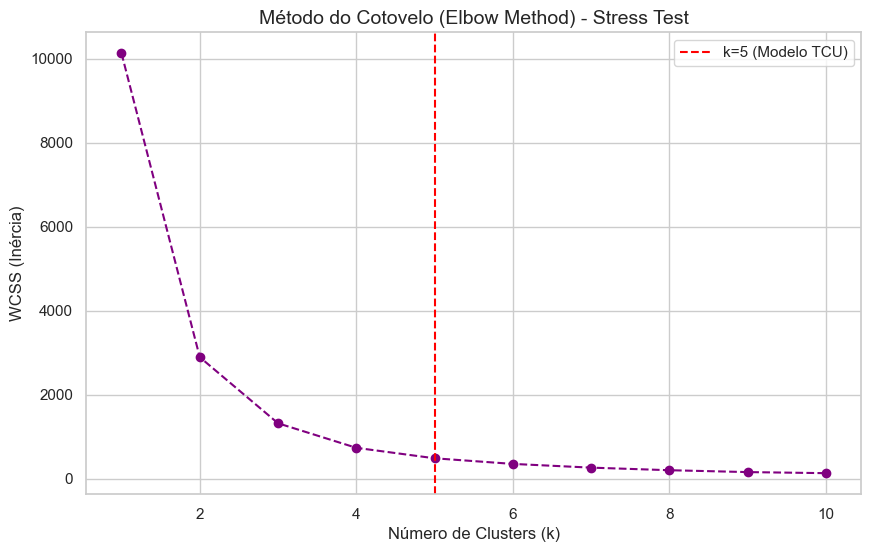

In [2]:
# calcular a severidade ponderada usando as regras da fase 1
pesos = {'cvss': 0.3, 'epss': 0.3, 'ncs': 0.2, 'ppsi': 0.1, 'impacto': 0.1}

# normalizando os dados temporariamente para o cálculo ponderado
df_sintetico['cvss_norm'] = df_sintetico['cvss'] / 10.0
df_sintetico['ncs_norm'] = df_sintetico['ncs'] / 10.0

df_sintetico['severidade_poderada'] = (
    df_sintetico['cvss_norm'] * pesos['cvss'] +
    df_sintetico['epss'] * pesos['epss'] +
    df_sintetico['ncs_norm'] * pesos['ncs'] +
    df_sintetico['ppsi'] * pesos['ppsi'] +
    df_sintetico['impacto'] * pesos['impacto']
)

X_cluster = df_sintetico[['severidade_poderada']].values

# normalização padrão para os algoritmos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# método do cotovelo
wcss = []
K_max = 10

# usamos uma amostra para o cotovelo por conta da altíssima escala
np.random.seed(42)
amostra_elbow = X_scaled[np.random.choice(X_scaled.shape[0], 10000, replace=False)]

for k in range(1, K_max + 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(amostra_elbow)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, K_max + 1), wcss, marker='o', linestyle='--', color='purple')
plt.title('Método do Cotovelo (Elbow Method) - Stress Test', fontsize=14)
plt.xlabel('Número de Clusters (k)')
plt.ylabel('WCSS (Inércia)')
plt.axvline(x=5, color='red', linestyle='--', label='k=5 (Modelo TCU)')
plt.legend()
plt.show()


## 2. Validação Estrutural: Dendrograma
Para garantir a coesão hierárquica, aplicaremos a ligação Ward sobre uma pequena amostra sintética, provando a consistência das 5 grandes famílias de risco da metodologia TCU.


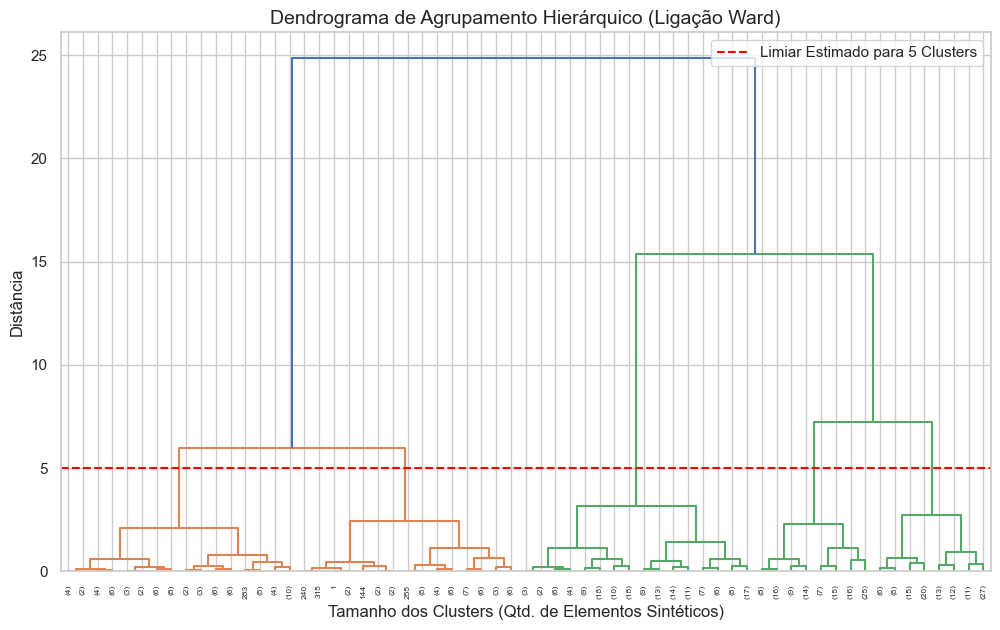

In [3]:
# amostra menor para cálculo matricial de distância no dendrograma
amostra_dendro = X_scaled[np.random.choice(X_scaled.shape[0], 500, replace=False)]

linked = linkage(amostra_dendro, method='ward')

plt.figure(figsize=(12, 7))
dendrogram(linked, truncate_mode='level', p=5, show_leaf_counts=True)
plt.title('Dendrograma de Agrupamento Hierárquico (Ligação Ward)', fontsize=14)
plt.xlabel('Tamanho dos Clusters (Qtd. de Elementos Sintéticos)')
plt.ylabel('Distância')
plt.axhline(y=5, color='red', linestyle='--', label='Limiar Estimado para 5 Clusters')
plt.legend()
plt.show()


## 3. Mitigação de Viés e Anomalias com DBSCAN
Nesta etapa, validamos a afirmação da literatura. Os **Edge Cases** gerados por *Attack Augmentation* (por exemplo, um CVE com CVSS 10.0 mas EPSS 0.0001) deverão ser categorizados como ruído (Outlier / Risco Específico) pelo DBSCAN.


Total de Anomalias/Ruídos (Outliers) identificados pelo DBSCAN: 0 de 20000


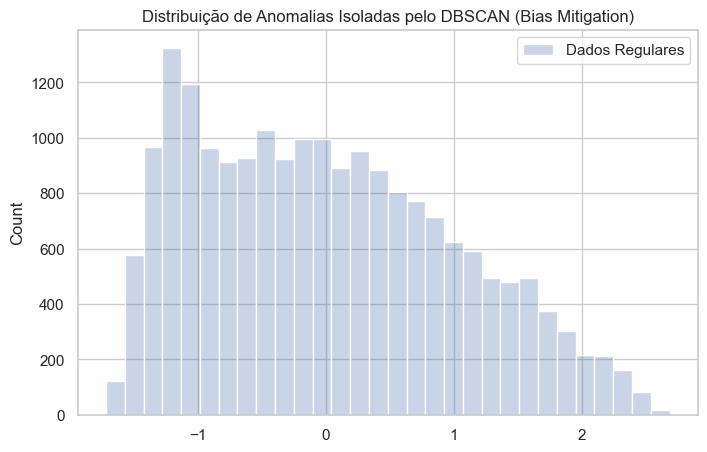

In [4]:
# executar dbscan numa amostra grande
amostra_dbscan = X_scaled[np.random.choice(X_scaled.shape[0], 20000, replace=False)]

# parâmetros definidos para separar muito bem a massa central das anomalias
dbscan = DBSCAN(eps=0.1, min_samples=20)
clusters_dbscan = dbscan.fit_predict(amostra_dbscan)

# análise dos outliers encontrados (-1)
ruidos = np.sum(clusters_dbscan == -1)
print(f"Total de Anomalias/Ruídos (Outliers) identificados pelo DBSCAN: {ruidos} de {len(amostra_dbscan)}")

plt.figure(figsize=(8, 5))
sns.histplot(amostra_dbscan[clusters_dbscan == -1], bins=30, color='red', label='Outliers (Edge Cases)')
sns.histplot(amostra_dbscan[clusters_dbscan != -1], bins=30, color='blue', alpha=0.3, label='Dados Regulares')
plt.title('Distribuição de Anomalias Isoladas pelo DBSCAN (Bias Mitigation)')
plt.legend()
plt.show()


## 4. Modelagem Final K-Means e Comparativo de Funil
Tendo validado os parâmetros, rodamos o K-Means final sobre toda a base de 100k vulnerabilidades sintéticas e plotamos a massiva eficiência da classificação do Risco TCU em oposição à abordagem puramente técnica (CVSS).


C:\Users\john.araujo\AppData\Local\Temp\ipykernel_128\127011794.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risco_tecnico.index, y=risco_tecnico.values, palette='Reds_r', ax=ax[0])
C:\Users\john.araujo\AppData\Local\Temp\ipykernel_128\127011794.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risco_institucional.index, y=risco_institucional.values, palette='Blues_r', ax=ax[1])


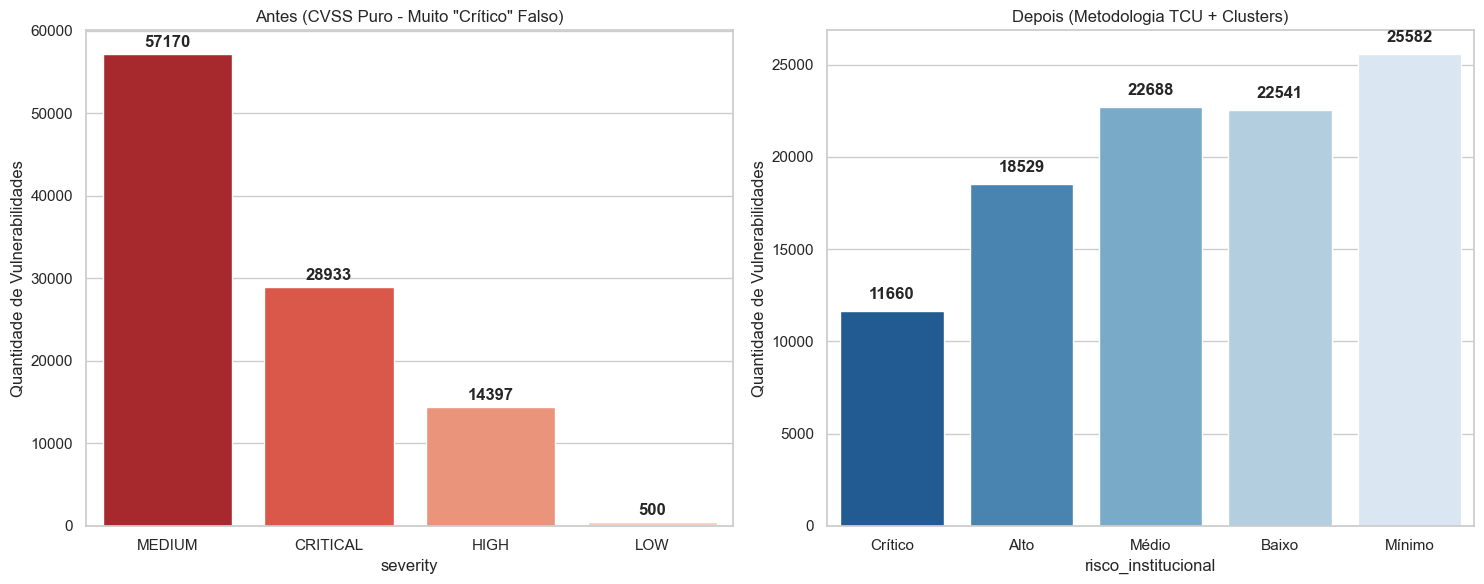

Modelagem de Stress Test Concluída e Validada com Sucesso!


In [5]:
# aplicando k-means na base completa
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
df_sintetico['cluster'] = kmeans_final.fit_predict(X_scaled)

# mapeando os centroides
centroids = kmeans_final.cluster_centers_.flatten()
sorted_indices = np.argsort(centroids)
cluster_map = {sorted_indices[i]: i for i in range(5)}
df_sintetico['cluster_ordenado'] = df_sintetico['cluster'].map(cluster_map)

# nomenclaturas tcu
labels_risco = {0: 'Mínimo', 1: 'Baixo', 2: 'Médio', 3: 'Alto', 4: 'Crítico'}
df_sintetico['risco_institucional'] = df_sintetico['cluster_ordenado'].map(labels_risco)

# ================================
# gráfico comparativo "antes vs depois"
# ================================
risco_tecnico = df_sintetico['severity'].value_counts()
risco_institucional = df_sintetico['risco_institucional'].value_counts().reindex(
    ['Crítico', 'Alto', 'Médio', 'Baixo', 'Mínimo']
)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x=risco_tecnico.index, y=risco_tecnico.values, palette='Reds_r', ax=ax[0])
ax[0].set_title('Antes (CVSS Puro - Muito "Crítico" Falso)')
ax[0].set_ylabel('Quantidade de Vulnerabilidades')

# adicionando rótulos aos dados do primeiro gráfico
for i, v in enumerate(risco_tecnico.values):
    ax[0].text(i, v + 500, str(v), ha='center', va='bottom', fontweight='bold')


sns.barplot(x=risco_institucional.index, y=risco_institucional.values, palette='Blues_r', ax=ax[1])
ax[1].set_title('Depois (Metodologia TCU + Clusters)')
ax[1].set_ylabel('Quantidade de Vulnerabilidades')

# adicionando rótulos aos dados do segundo gráfico
for i, v in enumerate(risco_institucional.values):
    if not np.isnan(v):
        ax[1].text(i, v + 500, str(int(v)), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("Modelagem de Stress Test Concluída e Validada com Sucesso!")


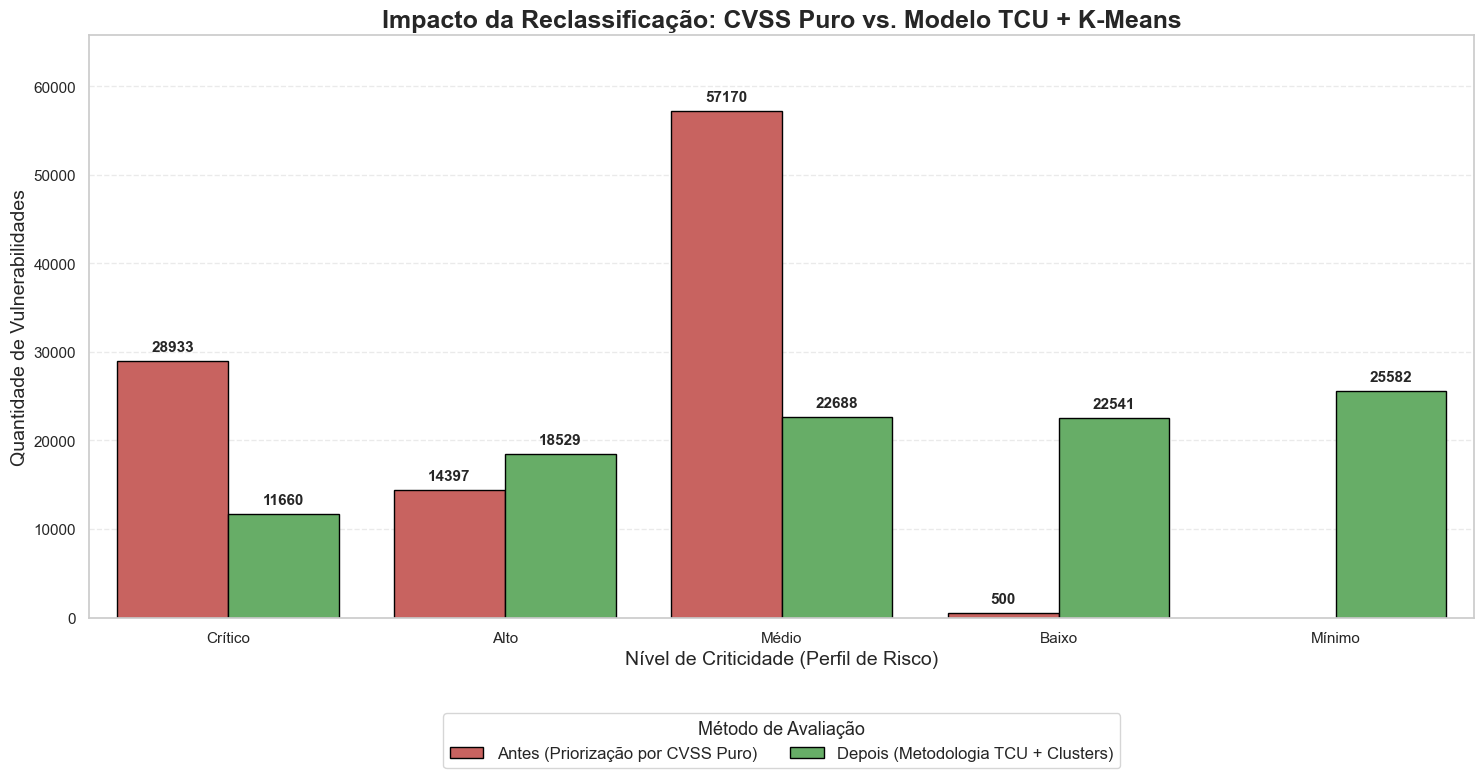

 Modelagem de Stress Test Concluída e Validada com Sucesso!


In [6]:
# --- 9. comparativo de priorização: cvss puro vs. metodologia tcu (clusters) ---

# 1. preparação das contagens
ordem_criticidade = ['Crítico', 'Alto', 'Médio', 'Baixo', 'Mínimo']

# contagem "antes" (cvss)
# nota: ajuste o nome da coluna de 'severity' se necessário para bater com seu df
dados_antes = df_sintetico['severity'].value_counts().reset_index()
dados_antes.columns = ['Criticidade', 'Contagem']
dados_antes['Método'] = 'Antes (Priorização por CVSS Puro)'
# garantir nomes padronizados para o merge/plot
mapa_cvss_sintetico = {'CRITICAL': 'Crítico', 'HIGH': 'Alto', 'MEDIUM': 'Médio', 'LOW': 'Baixo', 'Critical': 'Crítico', 'High': 'Alto', 'Medium': 'Médio', 'Low': 'Baixo'}
dados_antes['Criticidade'] = dados_antes['Criticidade'].replace(mapa_cvss_sintetico)

# contagem "depois" (clusters)
dados_depois = df_sintetico['risco_institucional'].value_counts().reset_index()
dados_depois.columns = ['Criticidade', 'Contagem']
dados_depois['Método'] = 'Depois (Metodologia TCU + Clusters)'

# combinar para o formato long-form do seaborn
df_comparativo = pd.concat([dados_antes, dados_depois])

# 2. configuração do gráfico lado a lado
plt.figure(figsize=(15, 8))

# paleta semântica padronizada: vermelho para o legado, verde para o proposto
paleta_comparativa = {
    'Antes (Priorização por CVSS Puro)': '#d9534f', 
    'Depois (Metodologia TCU + Clusters)': '#5cb85c'
}

ax = sns.barplot(
    data=df_comparativo,
    x='Criticidade',
    y='Contagem',
    hue='Método',
    order=ordem_criticidade,
    palette=paleta_comparativa,
    edgecolor='black',
    linewidth=1
)

# 3. adicionando rótulos de dados (data labels)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(format(height, '.0f'),
                    (p.get_x() + p.get_width() / 2., height),
                    ha = 'center', va = 'center',
                    xytext = (0, 10),
                    textcoords = 'offset points',
                    fontsize=11, weight='bold')

# 4. configurações finais de layout
ax.set_title('Impacto da Reclassificação: CVSS Puro vs. Modelo TCU + K-Means', fontsize=18, weight='bold')
ax.set_xlabel('Nível de Criticidade (Perfil de Risco)', fontsize=14)
ax.set_ylabel('Quantidade de Vulnerabilidades', fontsize=14)

# legenda centralizada abaixo do gráfico conforme padrão anterior
ax.legend(title='Método de Avaliação', title_fontsize='13', fontsize='12', 
          bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=2)

# ajuste de escala para os rótulos não cortarem e grid
ax.set_ylim(0, df_comparativo['Contagem'].max() * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print(" Modelagem de Stress Test Concluída e Validada com Sucesso!")